# L3b Advanced: Bootstrap Uncertainty in Lattice Calibration

The required L3b example produces one estimate of the binomial-lattice parameters $(u,d,p)$. Those values come from a finite historical sample, so another sample would give different estimates. This notebook measures that uncertainty and carries it into two lattice forecasts.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Calibrate:__ Estimate the up factor, down factor, and up-move probability from a historical growth-rate sample. Treat the result as a point estimate produced by one sample rather than a fixed property of the asset.
> * __Bootstrap:__ Build uncertainty intervals for calibrated parameters by resampling the historical data under a stated resampling rule. Propagate that parameter uncertainty into the expected terminal price and the probability that the terminal price exceeds its starting value.
> * __Validate:__ Compare a model estimated on one sample against a later sample it never saw. State what such a comparison establishes about sampling error and what it leaves untested about model structure.

The bootstrap measures sampling uncertainty under a chosen resampling rule. It does not prove that the fixed lattice is the correct model.

Let's get started!
___

## Setup, Data, and Prerequisites

We use the course market dataset and the same real-world estimator as the required L3b example.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # activate the course environment and load shared packages

The `Include.jl` file activates the course project and loads the course toolkit [VLQuantitativeFinancePackage.jl](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl) together with the [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Distributions.jl](https://juliastats.org/Distributions.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/), [Random](https://docs.julialang.org/en/v1/stdlib/Random/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), and [StatsBase.jl](https://juliastats.org/StatsBase.jl/stable/) packages. There are no local source files beyond `Include.jl` itself.

Next, we set the default plot styling and load the market dataset:

In [2]:
# Configure consistent plotting defaults for every calibration figure -
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :white,
    background_color_outside = :white,
    foreground_color = :gray20,
    legend_background_color = :white,
    fg_legend = :transparent,
    titlefontsize = 20,
    guidefontsize = 18,
    tickfontsize = 14,
    legendfontsize = 14,
    linewidth = 3.5,
    markersize = 6,
    markerstrokewidth = 0.8,
    gridalpha = 0.18,
    gridlinewidth = 0.7,
    size = (1000, 620),
    dpi = 160,
    left_margin = 9Plots.mm,
    right_margin = 7Plots.mm,
    bottom_margin = 9Plots.mm,
    top_margin = 7Plots.mm,
);

Load AAPL's historical prices and check the sample dates and observation counts.

In [3]:
# Load one complete historical calibration sample -
market_data = MyTrainingMarketDataSet() |> x -> x["dataset"] # ticker-to-DataFrame mapping
ticker = "AAPL" # firm calibrated in this worked example
firm_data = market_data[ticker] # historical daily prices for the selected firm
Δt = 1.0 / 252.0 # one trading-day step in units of trading years
growth_rates = log_growth_matrix(market_data, ticker) # annualized daily growth-rate observations

# Display the coverage of the calibration sample.
pretty_table(DataFrame(ticker = ticker, price_observations = nrow(firm_data),
        growth_observations = length(growth_rates),
        first_date = minimum(firm_data.timestamp), last_date = maximum(firm_data.timestamp));
    column_labels = ["Ticker", "Price observations", "Growth observations",
        "First date", "Last date"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,)

========= ==================== ===================== ===================== ======================
  Ticker   Price observations   Growth observations            First date             Last date 
========= ==================== ===================== ===================== ======================
    AAPL                 2767                  2766   2014-01-03T05:00:00   2024-12-31T05:00:00
========= ==================== ===================== ===================== ======================


___

## Task 1: Calibrate the lattice and forecast from it

In this task, we'll estimate one set of lattice parameters from the full sample of growth rates and compute two forecasts from them. These single numbers are the starting point, and Task 2 asks how much they would move if we had drawn a different sample.

The estimator averages the one-step multipliers $\exp(g_t\Delta t)$ separately over the positive and negative growth observations to obtain $\widehat u$ and $\widehat d$, and takes $\widehat p$ as the fraction of positive observations. These are historical summaries rather than fitted parameters of a stated distribution, and the method does not impose $\widehat d=1/\widehat u$.

Let's calibrate the lattice on the full sample:

In [4]:
# Wrap the course estimator so every resample uses the same time convention -
estimate_parameters(R::Vector{Float64}) =
    (RealWorldBinomialProbabilityMeasure())(R; Δt = Δt) # return fitted (u,d,p)

û, d̂, p̂ = estimate_parameters(growth_rates) # point estimates from the full sample
@assert !isapprox(d̂, 1 / û; rtol = 1e-6) # data-driven factors need not satisfy reciprocal symmetry
DataFrame(parameter = ["up factor u", "down factor d", "up probability p", "reciprocal 1/u"],
    estimate = [û, d̂, p̂, 1 / û])

Row,parameter,estimate
,String,Float64
1,up factor u,1.01059
2,down factor d,0.989301
3,up probability p,0.550976
4,reciprocal 1/u,0.989516


### Two forecasts computed from the calibration

The calibrated lattice gives us two forecasts: the expected terminal price and the probability that the terminal price exceeds its starting value. Both are model outputs, so uncertainty in $(u,d,p)$ becomes uncertainty in both.

For a horizon of $N$ steps, let $K_N$ be the number of up moves, so that $K_N\sim\operatorname{Binomial}(N,p)$ and the terminal price after $k$ up moves is $S_{N,k}=S_0u^kd^{N-k}$. Writing $S_N$ for the random terminal price, the probability that it exceeds $S_0$ is given by:
$$
\boxed{
P_{\mathrm{above}}:=\mathbb{P}(S_N>S_0)
=\sum_{k=0}^{N}\mathbf{1}_{\{S_0u^kd^{N-k}>S_0\}}\binom{N}{k}p^k(1-p)^{N-k}.
}
$$
Here $\mathbb{P}$ is the real-world probability rule defined by $p$, and $\mathbf{1}$ equals one when its condition holds and zero otherwise. For this notebook, $P_{\mathrm{above}}$ is also the probability of profit for one share bought at $S_0$ and sold after $N$ steps with no fees, bid-ask spread, slippage, dividends, or benchmark growth. We use the narrower label because [L4a](../../../../week-4/L4a/CHEME-5660-L4a-Lecture-LatticeModel-TradeRule-Fall-2026.ipynb) develops the general NPV-based probability-of-profit calculation.

Let's compute both forecasts from the point calibration:

In [5]:
# Evaluate the terminal-price distribution without materializing the full tree -
function terminal_forecast(S₀::Float64, u::Float64, d::Float64, p::Float64, h::Int)
    k = collect(0:h) # possible numbers of up moves after h steps
    prices = S₀ .* u .^ k .* d .^ (h .- k) # terminal USD/share aligned with each k
    probabilities = pdf.(Binomial(h, p), k) # probability mass for each up-move count
    return (expected_terminal_price = sum(prices .* probabilities),
        probability_above_start = sum(probabilities[prices .> S₀])) # strict terminal gain probability
end

S₀ = Float64(last(firm_data.volume_weighted_average_price)) # latest calibration-sample VWAP, USD/share
horizon = 21 # forecast horizon in trading-day steps, approximately one month
point_forecast = terminal_forecast(S₀, û, d̂, p̂, horizon) # forecast from point calibration
# Display the two forecasts produced by the point calibration.
pretty_table(DataFrame(ticker = ticker, starting_price = S₀, horizon_trading_days = horizon,
        expected_terminal_price = point_forecast.expected_terminal_price,
        probability_above_start = point_forecast.probability_above_start);
    column_labels = ["Ticker", "Starting price (USD/share)", "Horizon (trading days)",
        "Expected terminal price (USD/share)", "P(terminal price > start)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.4f", [2, 4]), fmt__printf("%.6f", [5])])

========= ============================ ======================== ===================================== ============================
  Ticker   Starting price (USD/share)   Horizon (trading days)   Expected terminal price (USD/share)   P(terminal price > start) 
========= ============================ ======================== ===================================== ============================
    AAPL                     250.7349                       21                              256.2325                    0.682263
========= ============================ ======================== ===================================== ============================


___

## Task 2: Bootstrap the calibration

In this task, we'll resample the growth-rate series, recalibrate on every resample, and carry the resulting spread through to the forecasts. We resample two ways, drawing single observations and drawing consecutive blocks, because the independent draw assumes away any dependence between consecutive days.

An independent bootstrap draws observations with replacement until the resample has the original length, which destroys any ordering in the series. A circular moving-block bootstrap instead draws short consecutive runs, so some local dependence survives inside each block. We draw 500 resamples under each rule, running the independent version first and the block version at the end of this task.

Let's resample the growth rates and recalibrate on each draw:

In [6]:
# Resample consecutive observations while wrapping blocks across the sample boundary -
function circular_block_sample(rng, R::Vector{Float64}, block_length::Int)
    draw = Float64[] # bootstrap sample grown until it reaches the original length
    while length(draw) < length(R)
        start = rand(rng, 1:length(R)) # uniformly sampled Julia start position
        append!(draw, [R[mod1(start + j - 1, length(R))] for j in 1:block_length]) # mod1 wraps into 1:length(R)
    end
    return draw[1:length(R)] # trim the final block to the original sample size
end

# Refit the lattice and propagate each bootstrap draw into terminal forecasts -
function bootstrap_calibration(R::Vector{Float64}; B::Int, block_length::Int,
    seed::Int, S₀::Float64, horizon::Int)
    rng = MersenneTwister(seed) # local generator prevents hidden dependence on global RNG state
    rows = NamedTuple[] # one fitted-parameter and forecast record per bootstrap draw
    for sample_index in 1:B # Julia sample positions 1,...,B
        draw = block_length == 1 ? R[rand(rng, 1:length(R), length(R))] : # i.i.d. resampling when length is one
            circular_block_sample(rng, R, block_length)
        u, d, p = estimate_parameters(draw) # refit all three lattice parameters
        forecast = terminal_forecast(S₀, u, d, p, horizon) # propagate calibration uncertainty
        push!(rows, (sample = sample_index, u = u, d = d, p = p,
            expected_terminal_price = forecast.expected_terminal_price,
            probability_above_start = forecast.probability_above_start))
    end
    return DataFrame(rows)
end

bootstrap_calibration (generic function with 1 method)

Run 500 independent resamples, then summarize the parameters and forecast values with central 95% bootstrap intervals.

In [7]:
# Generate independent bootstrap calibrations and percentile intervals -
B = 500 # number of bootstrap resamples
iid_bootstrap = bootstrap_calibration(growth_rates; B = B, block_length = 1,
    seed = 5660, S₀ = S₀, horizon = horizon)

interval_row(label, point, values) = (quantity = label, point_estimate = point, # summarize one bootstrap quantity
    bootstrap_mean = mean(values), lower_95 = quantile(values, 0.025),
    upper_95 = quantile(values, 0.975))

iid_intervals = DataFrame([ # point estimate, bootstrap mean, and central percentile interval
    interval_row("u", û, iid_bootstrap.u),
    interval_row("d", d̂, iid_bootstrap.d),
    interval_row("p", p̂, iid_bootstrap.p),
    interval_row("expected terminal price", point_forecast.expected_terminal_price, iid_bootstrap.expected_terminal_price),
    interval_row("P(S_N > S_0)", point_forecast.probability_above_start, iid_bootstrap.probability_above_start),
])

# Display the point estimate and the 95% bootstrap interval for each quantity.
pretty_table(iid_intervals;
    column_labels = ["Quantity", "Point estimate", "Bootstrap mean", "Lower 95%", "Upper 95%"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    fit_table_in_display_vertically = false,
    formatters = [fmt__printf("%.6f", [2, 3, 4, 5])])

========================== ================ ================ ============ =============
                 Quantity   Point estimate   Bootstrap mean    Lower 95%    Upper 95% 
========================== ================ ================ ============ =============
                        u         1.010595         1.010593     1.010102     1.011042
                        d         0.989301         0.989325     0.988730     0.989894
                        p         0.550976         0.551117     0.533623     0.569604
  expected terminal price       256.232459       256.305235   253.352069   259.210644
             P(S_N > S_0)         0.682263         0.678407     0.601202     0.741747
========================== ================ ================ ============ =============


The three panels below show where the resampled parameters landed. The red vertical line in each panel marks the point calibration from Task 1, so the width of the surrounding histogram is what the single estimate does not tell us.

Let's plot the bootstrap distribution of each parameter:

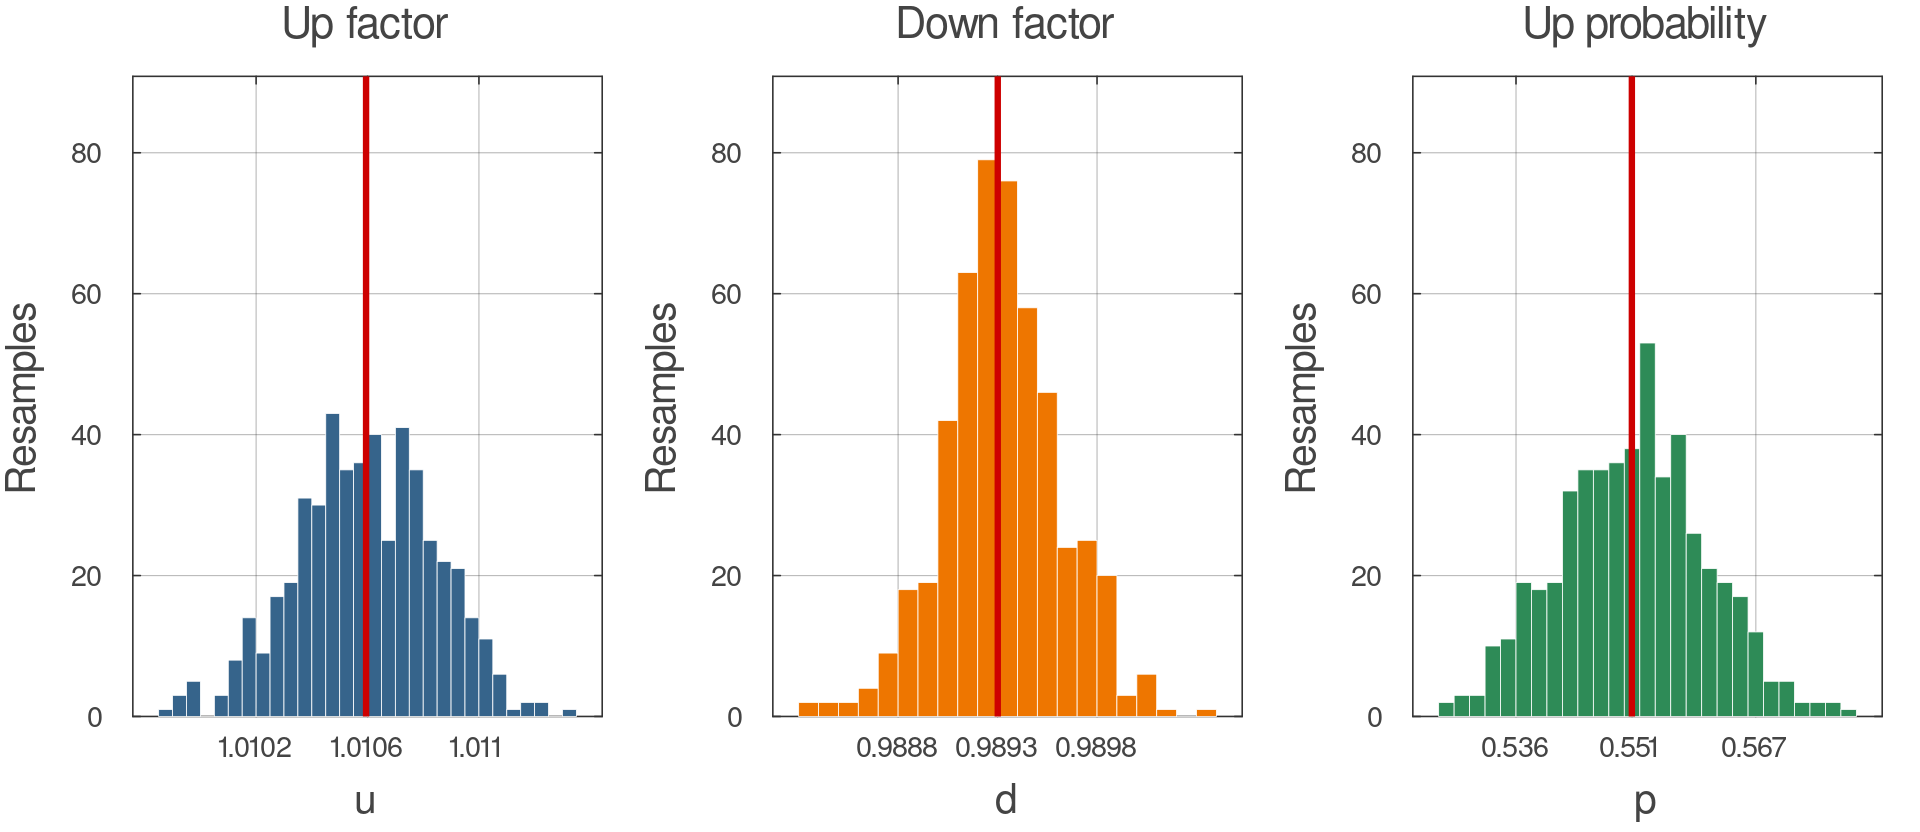

In [8]:
# Display bootstrap sampling distributions; red lines mark full-sample estimates -
p_u = histogram(iid_bootstrap.u; bins = 30, color = :steelblue4, linecolor = :white,
    linewidth = 0.5, label = "", xlabel = "u", ylabel = "Resamples", title = "Up factor",
    xticks = round.(quantile(iid_bootstrap.u, [0.05, 0.5, 0.95]); digits = 4),
    xformatter = x -> string(round(x; digits = 4)))
vline!(p_u, [û]; color = :red3, linewidth = 4, label = "")
p_d = histogram(iid_bootstrap.d; bins = 30, color = :darkorange2, linecolor = :white,
    linewidth = 0.5, label = "", xlabel = "d", ylabel = "Resamples", title = "Down factor",
    xticks = round.(quantile(iid_bootstrap.d, [0.05, 0.5, 0.95]); digits = 4),
    xformatter = x -> string(round(x; digits = 4)))
vline!(p_d, [d̂]; color = :red3, linewidth = 4, label = "")
p_p = histogram(iid_bootstrap.p; bins = 30, color = :seagreen4, linecolor = :white,
    linewidth = 0.5, label = "", xlabel = "p", ylabel = "Resamples", title = "Up probability",
    xticks = round.(quantile(iid_bootstrap.p, [0.05, 0.5, 0.95]); digits = 3))
vline!(p_p, [p̂]; color = :red3, linewidth = 4, label = "")
histogram_ylim = (0, 1.15 * maximum(last(ylims(p)) for p in (p_u, p_d, p_p))) # shared count scale with headroom
plot(p_u, p_d, p_p; layout = (1, 3), size = (1200, 520),
    ylims = histogram_ylim,
    titlefontsize = 18, guidefontsize = 17, tickfontsize = 12,
    left_margin = 6Plots.mm, right_margin = 4Plots.mm,
    bottom_margin = 8Plots.mm, top_margin = 6Plots.mm)

### Parameter uncertainty becomes forecast uncertainty

Each bootstrap sample changes $(u,d,p)$ and the two forecast summaries. The intervals measure uncertainty in the expected terminal price and the estimated probability of a gain. They are not prediction intervals for the future realized price.

Let's plot the two forecasts from every bootstrap sample against each other. The cloud shows how parameter uncertainty changes the two forecast summaries:

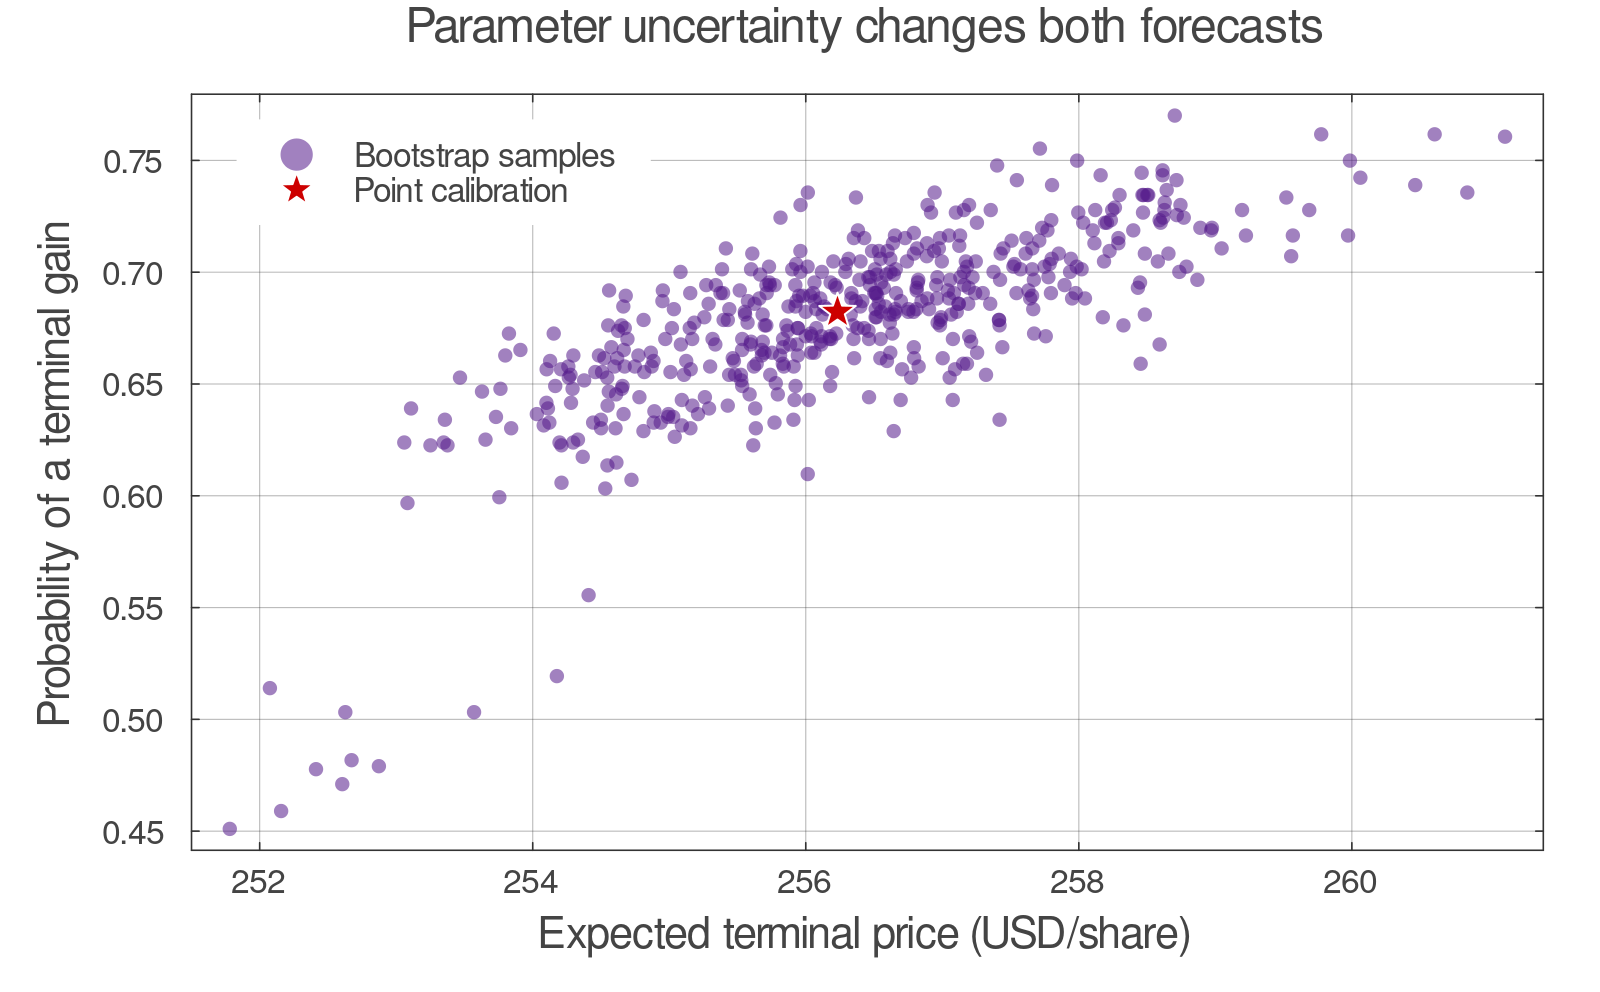

In [9]:
# Display how fitted-parameter uncertainty couples the two forecast summaries -
scatter(iid_bootstrap.expected_terminal_price, iid_bootstrap.probability_above_start;
    markersize = 5, markeralpha = 0.55, markerstrokewidth = 0, color = :purple4, label = "Bootstrap samples",
    xlabel = "Expected terminal price (USD/share)", ylabel = "Probability of a terminal gain",
    title = "Parameter uncertainty changes both forecasts", size = (1000, 620))
scatter!([point_forecast.expected_terminal_price], [point_forecast.probability_above_start];
    marker = :star5, markersize = 12, color = :red3, markerstrokewidth = 1,
    markerstrokecolor = :white, label = "Point calibration", legend = :topleft)

### Compare independent and block resampling

Finally, we rerun the bootstrap with 10-day blocks and compare the interval widths against the independent case, which shows whether keeping short runs of days intact changes the answer. We use 10-day blocks as a declared sensitivity case rather than as a uniquely correct choice.

Let's compare the widths of the central 95% bootstrap intervals under the two rules:

In [10]:
# Preserve short runs of observations with a ten-day circular block bootstrap -
block_bootstrap = bootstrap_calibration(growth_rates; B = B, block_length = 10,
    seed = 5661, S₀ = S₀, horizon = horizon)
interval_width(values) = quantile(values, 0.975) - quantile(values, 0.025) # central 95% percentile width

resampling_comparison = DataFrame( # compare uncertainty under independent and dependent resampling
    quantity = ["u", "d", "p", "expected terminal price", "P(S_N > S_0)"],
    iid_interval_width = interval_width.([iid_bootstrap.u, iid_bootstrap.d, iid_bootstrap.p,
        iid_bootstrap.expected_terminal_price, iid_bootstrap.probability_above_start]),
    block_interval_width = interval_width.([block_bootstrap.u, block_bootstrap.d, block_bootstrap.p,
        block_bootstrap.expected_terminal_price, block_bootstrap.probability_above_start]),
)

# Display the 95% interval width produced by each resampling rule.
pretty_table(resampling_comparison;
    column_labels = ["Quantity", "Independent interval width", "Block interval width"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    fit_table_in_display_vertically = false,
    formatters = [fmt__printf("%.6f", [2, 3])])

========================== ============================ =======================
                 Quantity   Independent interval width   Block interval width 
========================== ============================ =======================
                        u                     0.000940               0.001245
                        d                     0.001164               0.001590
                        p                     0.035982               0.041215
  expected terminal price                     5.858575               6.620807
             P(S_N > S_0)                     0.140545               0.172040
========================== ============================ =======================


___

## Task 3: Check the model against a holdout

In this task, we'll calibrate on the first 80% of the observations and compare the model's one-step summaries against the last 20%. Bootstrap intervals describe variation around the calibration sample, whereas validation asks a different question: does the fitted model still describe data it never saw?

Let's split the sample, recalibrate on the first portion, and compare against the rest:

In [11]:
# Split the ordered series so the final 20% is never used for calibration -
split_index = floor(Int, 0.80 * length(growth_rates)) # last Julia position in the training subset
calibration_rates = growth_rates[1:split_index] # first 80% in time order
holdout_rates = growth_rates[(split_index + 1):end] # final 20% in time order
u_train, d_train, p_train = estimate_parameters(calibration_rates) # training-only lattice parameters

# Compare model-implied and realized one-step summaries on the same scale -
calibration_model = [p_train, p_train * u_train + (1 - p_train) * d_train] # up frequency and mean factor
holdout_sample = [count(>(0.0), holdout_rates) / length(holdout_rates), # realized up frequency
    mean(exp.(holdout_rates .* Δt))] # realized mean one-step price multiplier
holdout_check = DataFrame( # one row for each held-out calibration diagnostic
    statistic = ["up frequency", "mean one-step multiplier"],
    calibration_model = calibration_model,
    holdout_sample = holdout_sample,
    difference = holdout_sample .- calibration_model,
)

# Display fitted-model summaries beside their observed holdout values -
pretty_table(holdout_check;
    column_labels = ["Statistic", "Fitted model", "Holdout sample", "Difference"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.6f", [2, 3, 4])])

=========================== ==================== ================ =============
                 Statistic         Fitted model   Holdout sample   Difference 
=========================== ==================== ================ =============
              up frequency             0.551085         0.550542    -0.000543
  mean one-step multiplier             1.001011         1.001122     0.000111
=========================== ==================== ================ =============


___

## Interpretation Limits

The bootstrap reports uncertainty intervals. The holdout comparison reports differences in two summaries; it sets no tolerance and makes no pass/fail decision.

* __Intervals depend on the resampling rule:__ Independent resampling removes time ordering; block resampling preserves short runs. The sample period, estimator, and block length affect the interval widths. These intervals measure parameter uncertainty and its effect on forecast summaries, not the full uncertainty in a future price.
* __Precision does not establish model accuracy:__ Narrow intervals do not show that a two-state lattice describes the market well.
* __The holdout comparison is limited:__ Similar up frequencies and mean multipliers do not establish agreement in tail behavior, volatility clustering, or the terminal-price distribution.

___

## Summary

This notebook measured the sampling uncertainty in a binomial-lattice calibration and carried that uncertainty into the two forecasts computed from the fitted model.

> __Key Takeaways:__
>
> * __A calibration is an estimate:__ A historical sample yields one draw of the up factor, down factor, and up-move probability. Resampling that data shows how far those values move under a different draw.
> * __Parameter uncertainty becomes forecast uncertainty:__ Every resampled calibration produces a different expected terminal price and probability that the terminal price exceeds its starting value. Interval widths depend on the resampling rule, because independent and block resampling preserve different features of the data.
> * __Validation is separate from calibration:__ A fitted model must be checked against observations that were not used to estimate it. Agreement in the two summaries supports only those aspects of the fit; it does not establish that a two-state lattice is structurally adequate.

A clear lattice report states the estimator, sample period, time step, uncertainty method, and validation result alongside the point estimates.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.